In [7]:
import pandas as pd
diabetes = pd.read_csv('../../datasets/diabetes.csv')
print(diabetes.head())

features = ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']
label = 'Diabetic'
X,y = diabetes[features], diabetes[label]

   PatientID  Pregnancies  PlasmaGlucose  DiastolicBloodPressure  \
0    1354778            0            171                      80   
1    1147438            8             92                      93   
2    1640031            7            115                      47   
3    1883350            9            103                      78   
4    1424119            1             85                      59   

   TricepsThickness  SerumInsulin        BMI  DiabetesPedigree  Age  Diabetic  
0                34            23  43.509726          1.213191   21         0  
1                47            36  21.240576          0.158365   23         0  
2                52            35  41.511523          0.079019   23         0  
3                25           304  29.582192          1.282870   43         1  
4                27            35  42.604536          0.549542   22         0  


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=0)

print("X_train shape: ", X_train.shape[0])
print("X_test shape: ", X_test.shape[0])

X_train shape:  10500
X_test shape:  4500


In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, roc_auc_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8962222222222223


In [11]:
print(y_pred)

[0 0 1 ... 1 1 0]


In [12]:
print(y_test.values)

[0 0 1 ... 1 1 1]


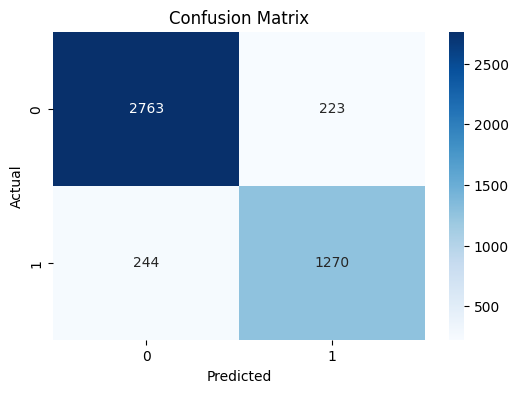

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
    

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2986
           1       0.85      0.84      0.84      1514

    accuracy                           0.90      4500
   macro avg       0.88      0.88      0.88      4500
weighted avg       0.90      0.90      0.90      4500



[[2763  223]
 [ 244 1270]]
Accuracy:  0.8962222222222223
Precision:  0.8506363027461487
F1 Score:  [0.92207576 0.84469571]
AUC Score:  0.8820778339428119


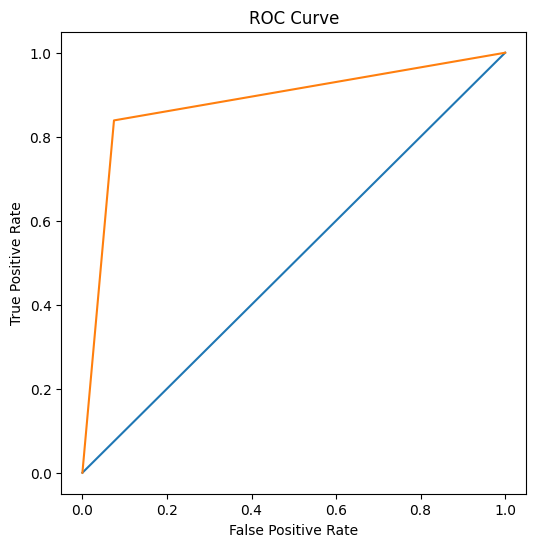

In [22]:
from sklearn.metrics import roc_curve

predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

cm = confusion_matrix(y_test, predictions)
print(cm)
print("Accuracy: ", accuracy_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))
print("F1 Score: ", f1_score(y_test, predictions, average=None))
auc=roc_auc_score(y_test, y_scores[:,1])
print("AUC Score: ", str(auc))


fpr, tpr, thresholds = roc_curve(y_test, y_scores[:, 1])

fig = plt.figure(figsize=(6,6))

plt.plot([0,1], [0,1])
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

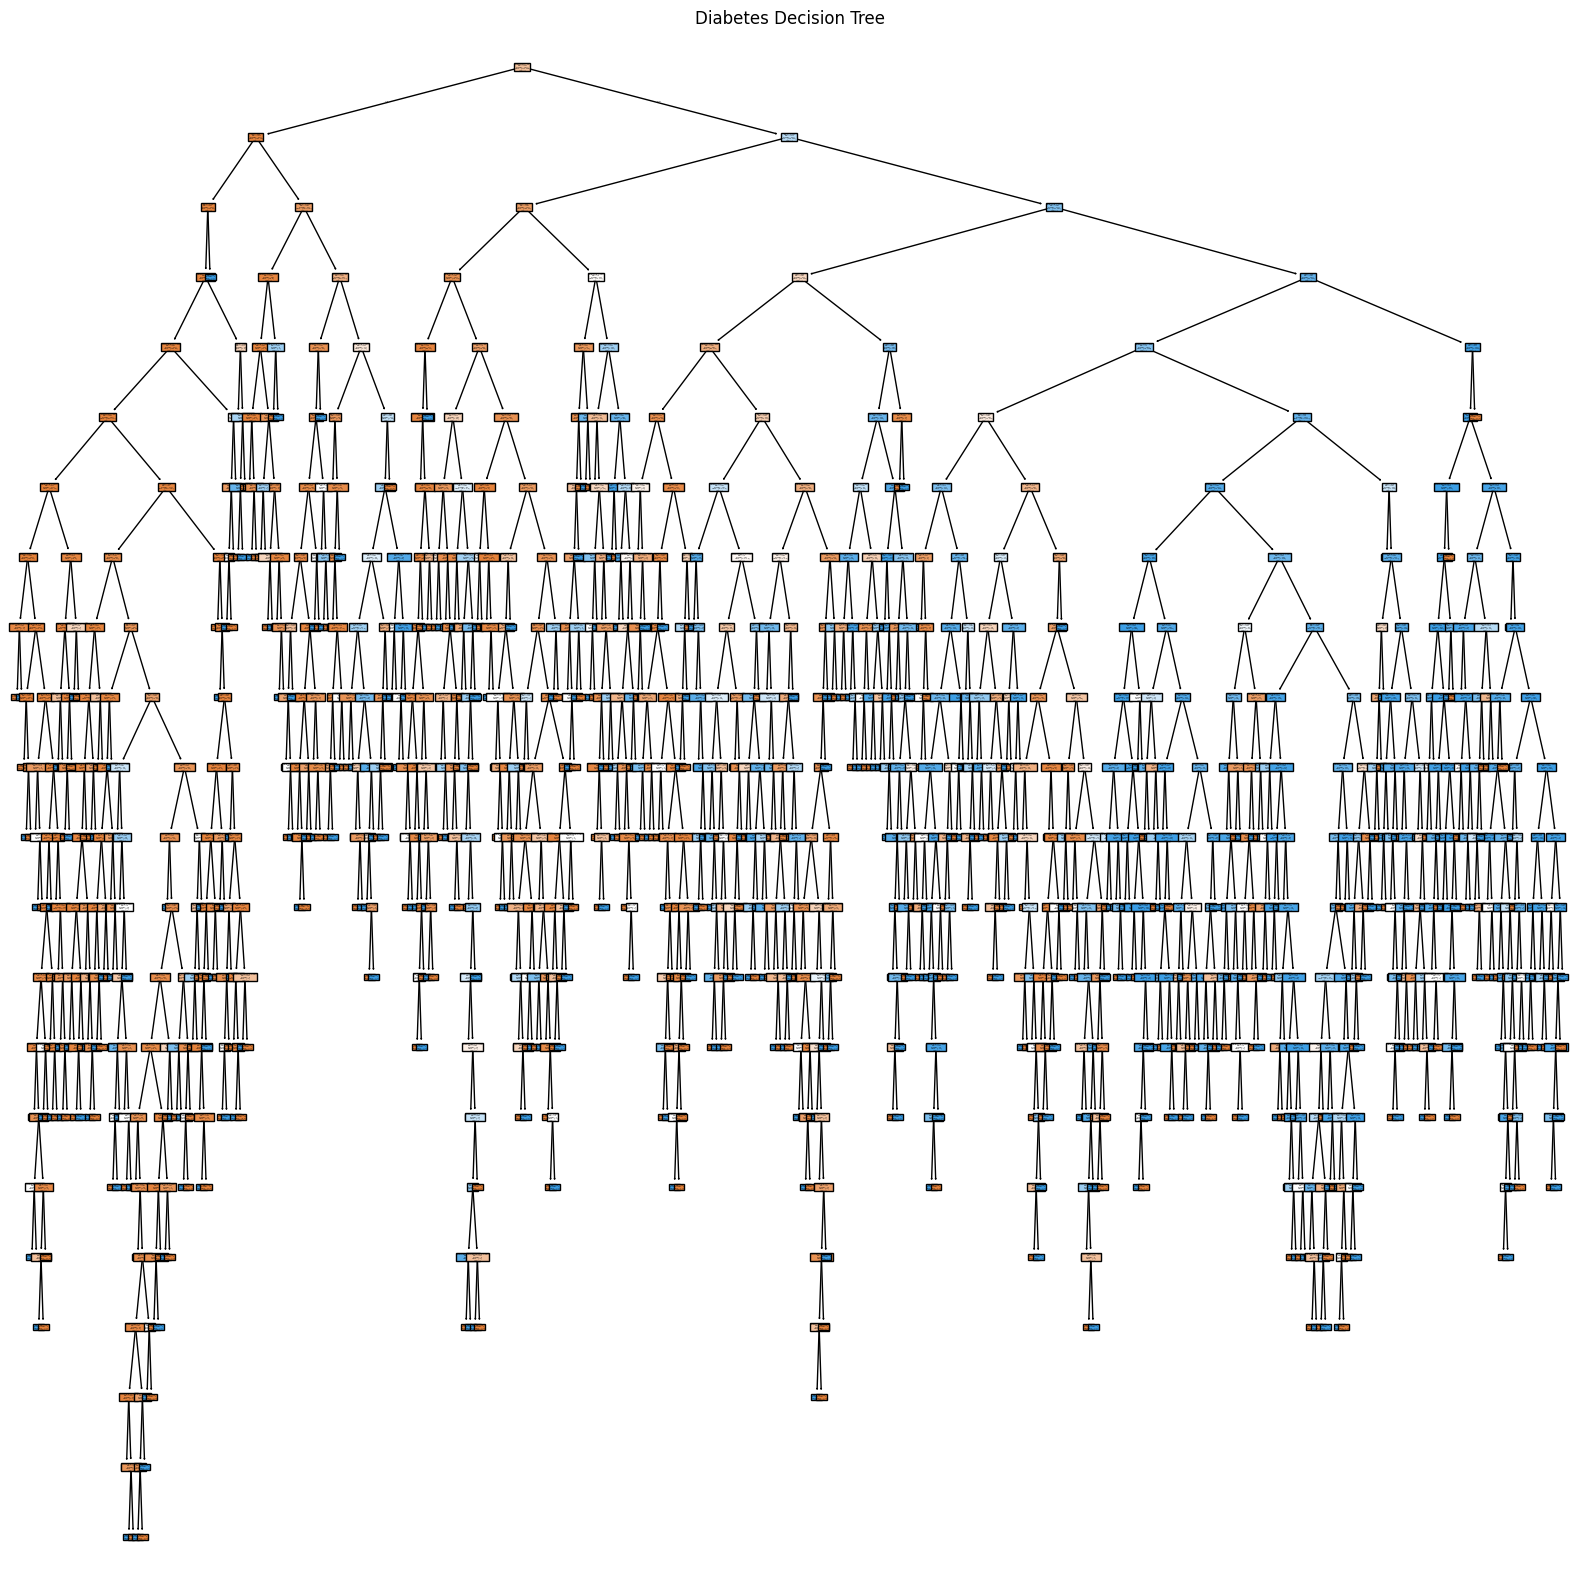

In [24]:
plt.figure(figsize=(20,20))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.title("Diabetes Decision Tree") 
plt.show()

In [25]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8531111111111112


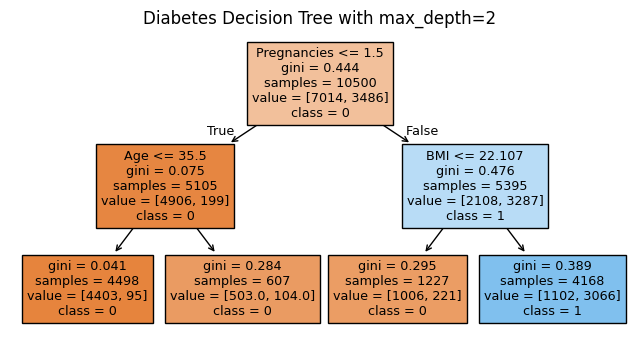

In [26]:
plt.figure(figsize=(8,4))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.title("Diabetes Decision Tree with max_depth=2")
plt.show()

<Axes: title={'center': 'Confusion Matrix with max_depth=2'}>

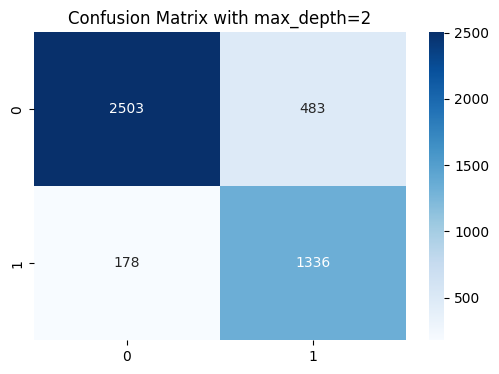

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with max_depth=2')
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88      2986
           1       0.73      0.88      0.80      1514

    accuracy                           0.85      4500
   macro avg       0.83      0.86      0.84      4500
weighted avg       0.87      0.85      0.86      4500



In [30]:
model = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.8957777777777778


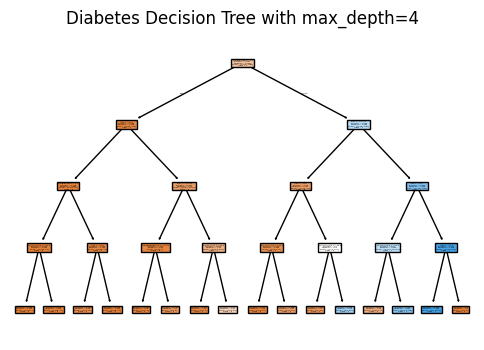

In [31]:
plt.figure(figsize=(6,4))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.title("Diabetes Decision Tree with max_depth=4")
plt.show()


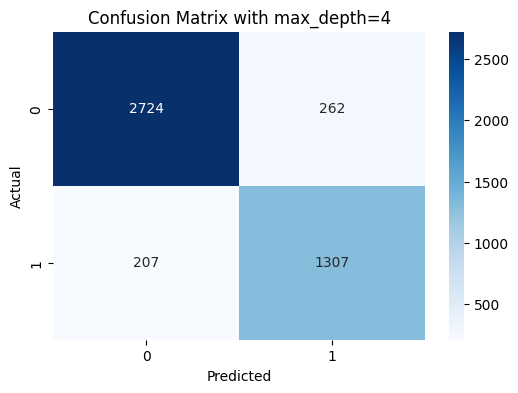

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with max_depth=4')
plt.show()


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2986
           1       0.83      0.86      0.85      1514

    accuracy                           0.90      4500
   macro avg       0.88      0.89      0.88      4500
weighted avg       0.90      0.90      0.90      4500



In [37]:
model = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)




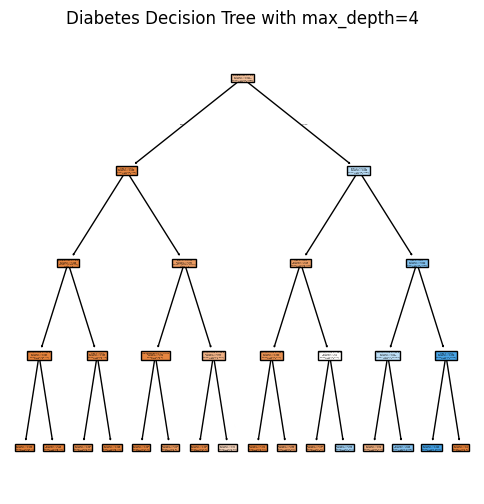

In [39]:
plt.figure(figsize=(6,6))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.title("Diabetes Decision Tree with max_depth=4")
plt.show()

In [40]:
model = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8735555555555555


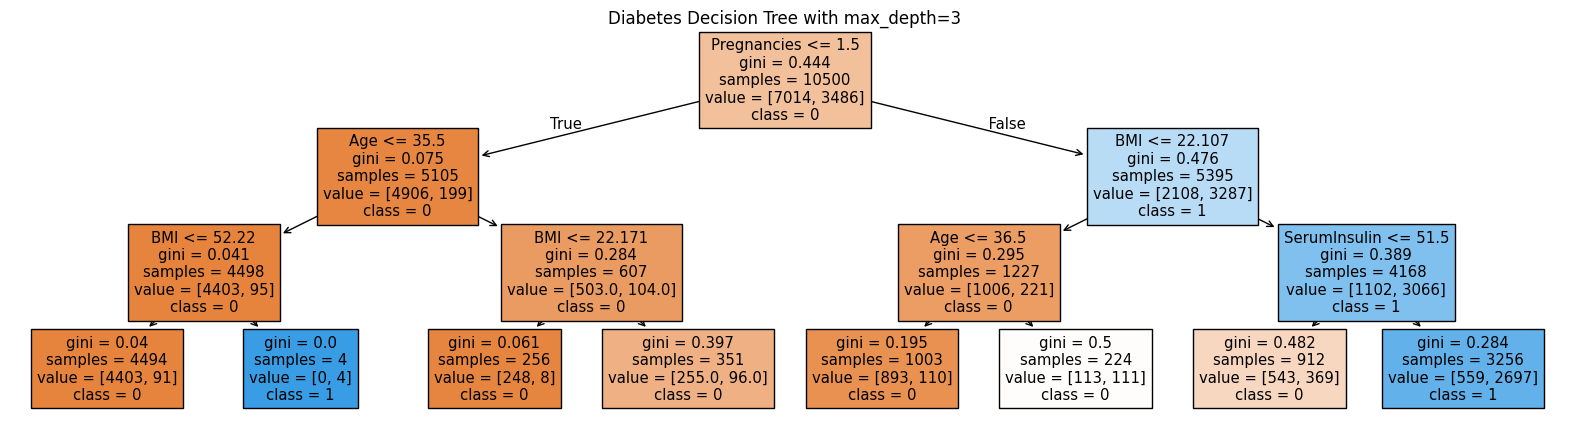

In [41]:
plt.figure(figsize=(20,5))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.title("Diabetes Decision Tree with max_depth=3")
plt.show()

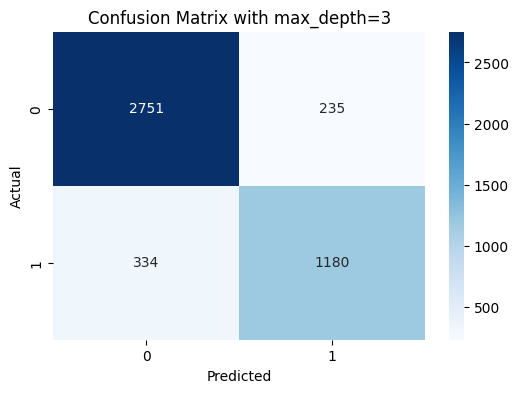

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix    

cnm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cnm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with max_depth=3')  
plt.show()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline   
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np




In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

numeric_features = [0, 1, 2, 3, 4, 5, 6]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_features = [7]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('DecisionTreeClassifier', DecisionTreeClassifier())
])

model = pipeline.fit(X_train, y_train)
print(model)
categorical_features = [7]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])  

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('DecisionTreeClassifier', DecisionTreeClassifier())
])  

model = pipeline.fit(X_train, (y_train))
print(model)
  



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('DecisionTreeClassifier', DecisionTreeClassifier())])
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                          

In [45]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('DecisionTreeClassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','PlasmaGlucose','DiastolicBloodPressure',...,'BMI', 'DiabetesPedigree','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [48]:
y_pred_pipeline = pipeline.predict(X_test)
print(y_pred_pipeline)

accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)

print("Accuracy: ", accuracy_pipeline)

[0 0 1 ... 1 1 0]
Accuracy:  0.8895555555555555


In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Accuracy:  0.9502222222222222


In [50]:
print(y_pred)

[0 0 1 ... 1 1 1]


In [51]:
print(y_test.values)

[0 0 1 ... 1 1 1]


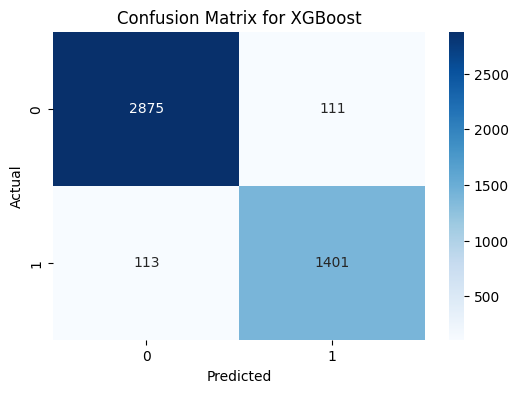

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix    

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))       
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2986
           1       0.93      0.93      0.93      1514

    accuracy                           0.95      4500
   macro avg       0.94      0.94      0.94      4500
weighted avg       0.95      0.95      0.95      4500



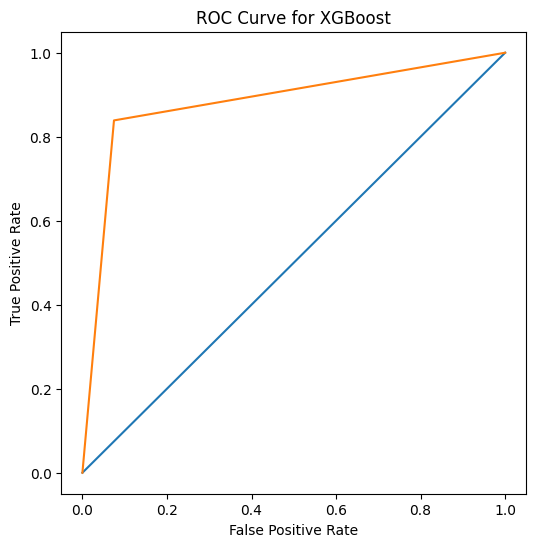

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:, 1])

flg = plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1])
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.show()
